In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
twenty_four = pd.read_csv('data/ncei_noaa/StormEvents_details-ftp_v1.0_d2024_c20250122.csv')
coastlines = {
    "CALIFORNIA", "OREGON", "WASHINGTON", 
    "TEXAS", "LOUISIANA", "MISSISSIPPI", "ALABAMA", "FLORIDA",
    "GEORGIA", "SOUTH CAROLINA", "NORTH CAROLINA", "VIRGINIA", 
    "MARYLAND", "DELAWARE", "NEW JERSEY", "NEW YORK", 
    "CONNECTICUT", "RHODE ISLAND", "MASSACHUSETTS", 
    "NEW HAMPSHIRE", "MAINE"
}
northeast = {
    "MAINE", "NEW HAMPSHIRE", "MASSACHUSETTS", 
    "RHODE ISLAND", "CONNECTICUT", "NEW YORK", "NEW JERSEY"
}

gulf = {"TEXAS", "LOUISIANA", "MISSISSIPPI", "ALABAMA", "FLORIDA", "GEORGIA"}

In [36]:
twenty_four[twenty_four['EVENT_TYPE'] == 'Storm Tide']

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'ALABAMA'),
  Text(1, 0, 'CALIFORNIA'),
  Text(2, 0, 'CONNECTICUT'),
  Text(3, 0, 'DELAWARE'),
  Text(4, 0, 'FLORIDA'),
  Text(5, 0, 'GEORGIA'),
  Text(6, 0, 'LOUISIANA'),
  Text(7, 0, 'MAINE'),
  Text(8, 0, 'MARYLAND'),
  Text(9, 0, 'MASSACHUSETTS'),
  Text(10, 0, 'MISSISSIPPI'),
  Text(11, 0, 'NEW HAMPSHIRE'),
  Text(12, 0, 'NEW JERSEY'),
  Text(13, 0, 'NEW YORK'),
  Text(14, 0, 'NORTH CAROLINA'),
  Text(15, 0, 'OREGON'),
  Text(16, 0, 'RHODE ISLAND'),
  Text(17, 0, 'SOUTH CAROLINA'),
  Text(18, 0, 'TEXAS'),
  Text(19, 0, 'VIRGINIA'),
  Text(20, 0, 'WASHINGTON')])

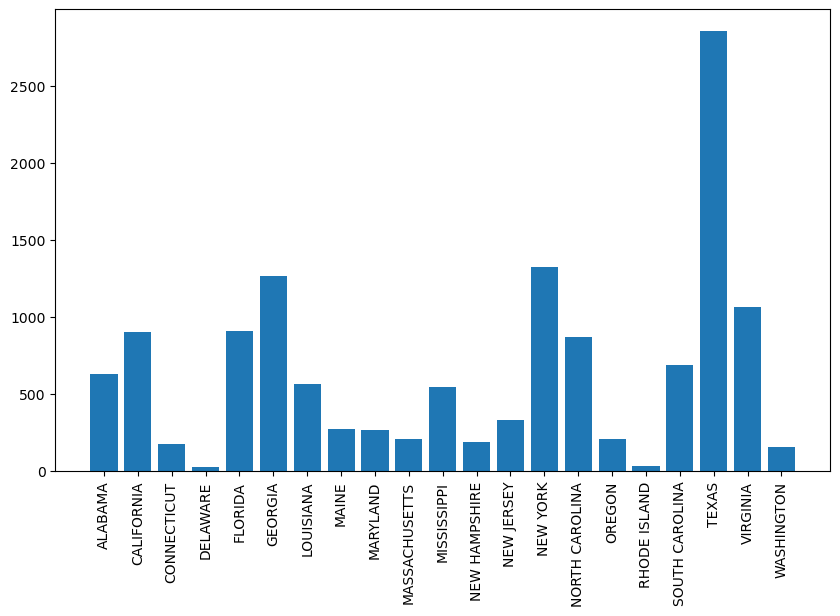

In [38]:
def is_coast(state):
    return state in coastlines

def filter_storm(storm):
    return storm in {'Hail', 'Blizzard', 'Heavy Rain', 'Heavy Snow', 'High Wind', 'Hail', 'Hurricane', 
                     'Lightning', 'Marine Hail', 'Marine High Wind', 'Tropical Storm',
                     'Winter Storm', 'Tropical Depression', 'Thunderstorm Wind', 'Sleet', 'Ice Storm'}

def filter_df(df):
    states= df[df['STATE'].transform(is_coast)]
    return states[states['EVENT_TYPE'].transform(filter_storm)]

twenty_four = filter_df(twenty_four)
grouped_state = twenty_four.groupby('STATE')['YEAR'].count()
plt.figure(figsize=(10, 6))
plt.bar(grouped_state.index, grouped_state)
plt.xticks(rotation=90)

In [44]:
twenty_four[twenty_four['STATE'].transform(lambda x: x in northeast)].shape[0]

4040

In [46]:
twenty_four[twenty_four['STATE'].transform(lambda x: x in gulf)].shape[0]

10304

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'ALABAMA'),
  Text(1, 0, 'CALIFORNIA'),
  Text(2, 0, 'CONNECTICUT'),
  Text(3, 0, 'DELAWARE'),
  Text(4, 0, 'FLORIDA'),
  Text(5, 0, 'GEORGIA'),
  Text(6, 0, 'LOUISIANA'),
  Text(7, 0, 'MAINE'),
  Text(8, 0, 'MARYLAND'),
  Text(9, 0, 'MASSACHUSETTS'),
  Text(10, 0, 'MISSISSIPPI'),
  Text(11, 0, 'NEW HAMPSHIRE'),
  Text(12, 0, 'NEW JERSEY'),
  Text(13, 0, 'NEW YORK'),
  Text(14, 0, 'NORTH CAROLINA'),
  Text(15, 0, 'OREGON'),
  Text(16, 0, 'RHODE ISLAND'),
  Text(17, 0, 'SOUTH CAROLINA'),
  Text(18, 0, 'TEXAS'),
  Text(19, 0, 'VIRGINIA'),
  Text(20, 0, 'WASHINGTON')])

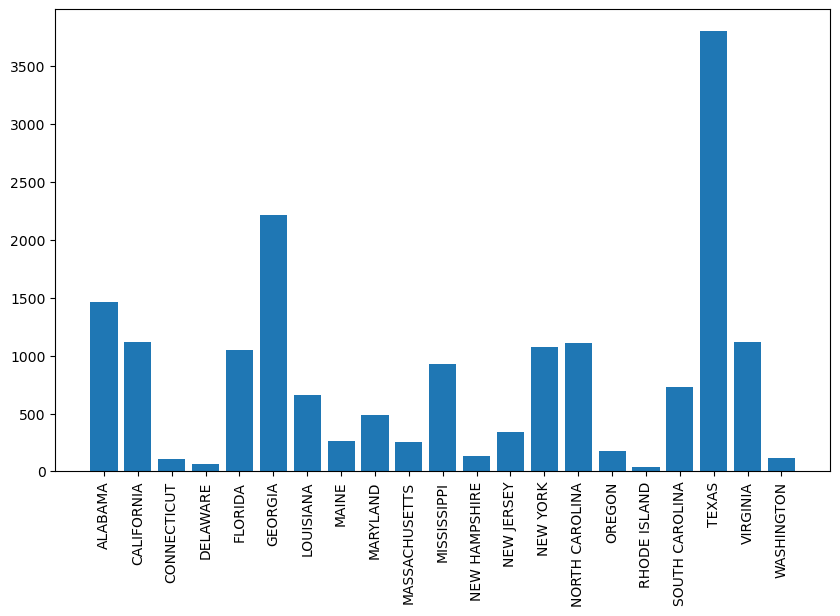

In [39]:
twenty_three = pd.read_csv('data/ncei_noaa/StormEvents_details-ftp_v1.0_d2023_c20241216.csv')
twenty_three = filter_df(twenty_three)
grouped_state = twenty_three.groupby('STATE')['YEAR'].count()
plt.figure(figsize=(10, 6))
plt.bar(grouped_state.index, grouped_state)
plt.xticks(rotation=90)

In [40]:
twenty_three.shape[0]

17245